<a href="https://colab.research.google.com/github/Maniganiga404/AML/blob/main/AML6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#LAB6


# import lib
# dataset (student hour/employee)
# declare the independent and dependent variable
# split the data
# call the linear regression model
# training
# calculate evaluation metrices(mse, rmse, r^2)
# evaulate the regression line


# Imports

import kagglehub
import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from kagglehub import KaggleDatasetAdapter

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)


In [34]:
file_path_emp = "Employee_Salary_Dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "anninasimon/employee-salary-dataset",
    file_path_emp
)

df.head()

Using Colab cache for faster access to the 'employee-salary-dataset' dataset.


,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


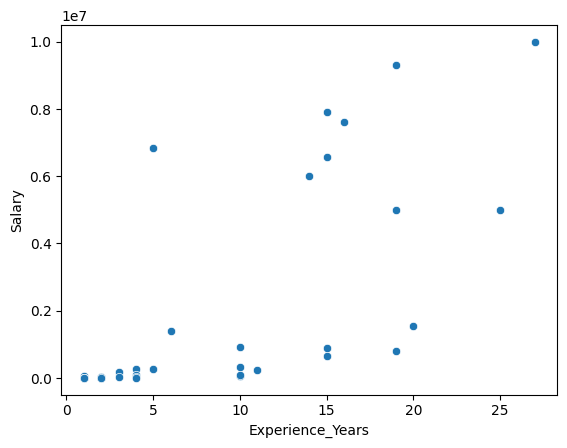

In [35]:

sns.scatterplot(data=df, x="Experience_Years", y="Salary")
plt.show()

In [36]:

df["log_salary"] = np.log1p(df["Salary"])


In [37]:
X = df[['Experience_Years']]
y = df['log_salary']

display(X.head())
display(y.head())

,Experience_Years
0,5
1,1
2,3
3,2
4,1


,log_salary
0,12.429220
1,10.819798
2,12.043560
3,10.126671
4,9.210440


In [38]:
display(df.info())
display(df.head())
display(df.describe())
display(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                35 non-null     int64  
 1   Experience_Years  35 non-null     int64  
 2   Age               35 non-null     int64  
 3   Gender            35 non-null     object 
 4   Salary            35 non-null     int64  
 5   log_salary        35 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 1.8+ KB


None

,ID,Experience_Years,Age,Gender,Salary,log_salary
0,1,5,28,Female,250000,12.429220
1,2,1,21,Male,50000,10.819798
2,3,3,23,Female,170000,12.043560
3,4,2,22,Male,25000,10.126671
4,5,1,17,Male,10000,9.210440


,ID,Experience_Years,Age,Salary,log_salary
count,35.000000,35.00000,35.000000,3.500000e+01,35.000000
mean,18.000000,9.20000,35.485714,2.059147e+06,12.358911
std,10.246951,7.55295,14.643552,3.170124e+06,2.633964
min,1.000000,1.00000,17.000000,3.000000e+03,8.006701
25%,9.500000,2.50000,22.500000,2.250000e+04,10.015104
50%,18.000000,6.00000,29.000000,2.500000e+05,12.429220
75%,26.500000,15.00000,53.500000,3.270000e+06,14.836121
max,35.000000,27.00000,62.000000,1.000000e+07,16.118096


Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary', 'log_salary'], dtype='object')

In [39]:
# Training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
# Call the linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [41]:
print("Actual:")
print(y_test.values)

print("Predicted:")
print(y_pred)

Actual:
[ 8.00670085 12.30184181  9.09391891 10.1266711  11.37367489  8.71620797
 12.70685096]
Predicted:
[10.48624494 13.06846113 11.2609098  11.2609098  11.2609098  10.74446656
 12.81023951]


In [42]:
# Calculate the evaluation metrices
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MEAN SQUARE ERROR     : ", mse)
print("ROOT MEAN SQUARE ERROR: ", rmse)
print("R^2 score             : ", r2)

MEAN SQUARE ERROR     :  2.4079184399161826
ROOT MEAN SQUARE ERROR:  1.5517468994382373
R^2 score             :  0.1654936936436472


In [43]:
# Regression equation
print("INTERCEPT  : ", model.intercept_)
print("COEFFICIENT: ", model.coef_)

print(f"REGRESSION EQUATION:\nPACKAGE = {model.intercept_:.4f} + {model.coef_[0]:.4f} * CGPA")

INTERCEPT  :  10.228023321989811
COEFFICIENT:  [0.25822162]
REGRESSION EQUATION:
PACKAGE = 10.2280 + 0.2582 * CGPA


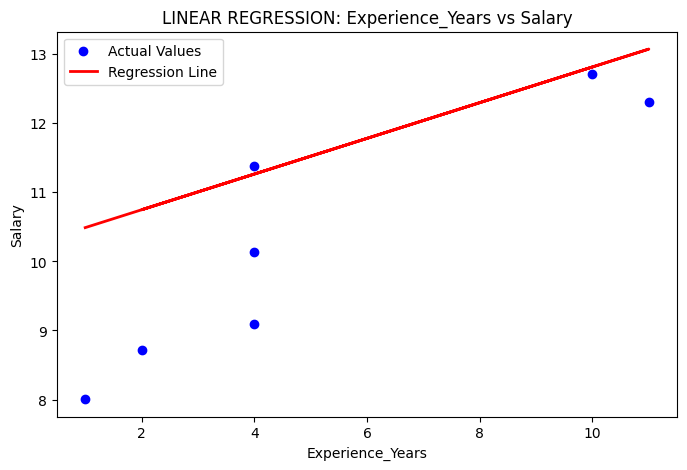

In [44]:
# Evaluate the regression line
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Values"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Experience_Years")
plt.ylabel("Salary")
plt.title("LINEAR REGRESSION: Experience_Years vs Salary")
plt.legend()
plt.show()


In [45]:
new_experience = [[8]]

prediction = model.predict(new_experience)

print("Predicted Salary:", prediction[0])

Predicted Salary: 12.293796271759


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
